In [16]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score

In [3]:
df = pd.read_csv('data/glass.csv')
df.sample(5)


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
95,1.51860,13.36,3.43,1.43,72.26,0.51,8.60,0.00,0.0,2
102,1.51820,12.62,2.76,0.83,73.81,0.35,9.42,0.00,0.2,2
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7
31,1.51747,12.84,3.50,1.14,73.27,0.56,8.55,0.00,0.0,1


In [6]:
df['Type'].unique()

array([1, 2, 3, 5, 6, 7], dtype=int64)

In [8]:
X = df.drop(['Type'],axis=1)
y = df['Type']

In [11]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)

In [15]:
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [17]:
y_pred  = knn.predict(X_test)

In [19]:
accuracy_score(y_test,y_pred)

0.813953488372093

In [20]:
score = []

for i in range(1,20):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    y_pred = knn.predict(X_test)
    score.append(accuracy_score(y_test,y_pred))
    

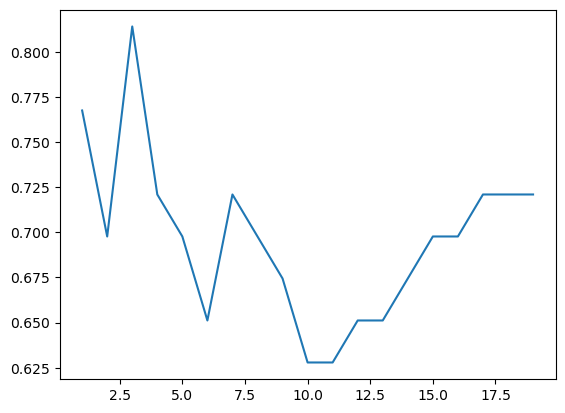

In [21]:
import matplotlib.pyplot as plt

plt.plot(range(1,20),score)